In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary
from networkx.classes import non_neighbors

sns.set_theme(style="white")

In [2]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [3]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)

In [4]:
design_matrix['survival_days'] = design_matrix['survival_days'].fillna(design_matrix['survival_days'].max())

In [5]:
design_matrix_test['survival_days'] = design_matrix_test['survival_days'].fillna(design_matrix_test['survival_days'].max())

In [6]:
design_matrix['organ_dysfunction'] = ((design_matrix[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)
design_matrix_test['organ_dysfunction'] = ((design_matrix_test[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)

In [7]:
design_matrix.shape

(680, 66)

In [8]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [9]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(training_data[clinical_columns])

training_data['PCA 1'] = components[:, 0]
training_data['PCA 2'] = components[:, 1]

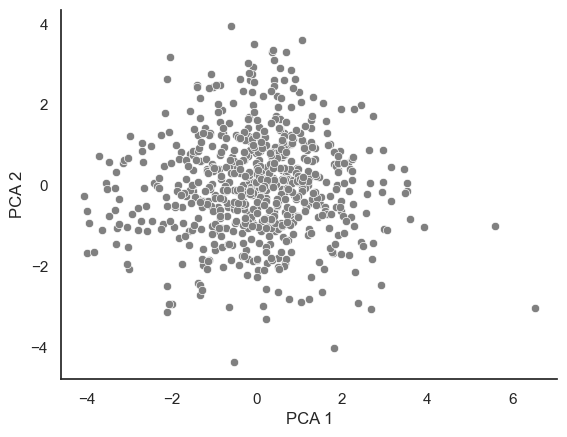

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    x='PCA 1',
    y='PCA 2',
    #hue="sepsis_or_septic_shock",
    ax=ax,
    c="gray"
)

sns.despine()

fig.savefig(
    "sepsis_or_septic_shock.pdf", dpi=300, bbox_inches="tight"
)

In [18]:
from sklearn.cluster import OPTICS

optcs_model = OPTICS(
    min_samples=10,
)

optcs_model.fit(training_data[clinical_columns])

,min_samples,10
,max_eps,inf
,metric,'minkowski'
,p,2
,metric_params,None
,cluster_method,'xi'
,eps,None
,xi,0.05
,predecessor_correction,True
,min_cluster_size,None
,algorithm,'auto'


In [19]:
optics_results = pd.DataFrame(
    {
        "sample": training_data.index.values,
        "reachability": optcs_model.reachability_[optcs_model.ordering_],
        "label": optcs_model.labels_[optcs_model.ordering_],
    }
)

In [20]:
optics_results

,sample,reachability,label
0,0,inf,0
1,1,2.275690,0
2,2,2.179884,0
3,3,2.179884,0
4,4,1.996258,0
...,...,...,...
675,675,4.527644,0
676,676,4.685642,0
677,677,4.787684,0
678,678,4.882004,0


In [21]:
optics_results['label'].value_counts()

label
0    680
Name: count, dtype: int64

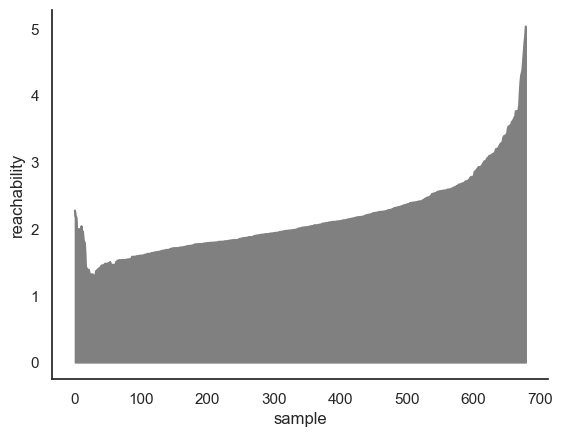

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.lineplot(
    data=optics_results,
    x="sample",
    y="reachability",
    ax=ax,
    c="gray"
)

ax.fill_between(
    optics_results['sample'],
    optics_results['reachability'],
    #alpha=0.3,
    color="gray"
)

sns.despine()

fig.savefig(
    "optics_results.pdf", dpi=300, bbox_inches="tight"
)

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans

class ConsensusClustering:

    def __init__(self, n_clusters=2, random_state=0, n_runs=20, subsample=0.9):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_runs = n_runs
        self.subsample = subsample

    def fit_transform(self, X: pd.DataFrame):

        self.coassoc_matrix = np.zeros((X.shape[0], X.shape[0]))

        for run in range(self.n_runs):

            X_ = X.sample(frac=self.subsample, replace=False)

            kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)

            labels = kmeans.fit_predict(X_)

            for i, idxi in enumerate(X_.index):

                for j, idxj in enumerate(X_.index):

                    if labels[i] == labels[j]:

                        self.coassoc_matrix[idxi, idxj] += 1

        self.coassoc_matrix /= self.n_runs

        linked = linkage(1 - self.coassoc_matrix, method="average")

        return fcluster(linked, t=self.n_clusters, criterion="maxclust")



In [25]:
from scipy.stats import ecdf
from statsmodels.distributions.empirical_distribution import ECDF

clusterer_results = dict()

cdfs = dict()

range_n_clusters = range(2, 11)

for n_cluster in range_n_clusters:

    consensus_clusterer = ConsensusClustering(
        n_clusters=n_cluster,
        n_runs=100,
    )

    training_data[f'Consensus Labels{n_cluster}'] = consensus_clusterer.fit_transform(training_data[clinical_columns])

    clusterer_results[n_cluster] = consensus_clusterer

    consensus_values = consensus_clusterer.coassoc_matrix[np.triu_indices_from(consensus_clusterer.coassoc_matrix, k=1)]

    cdfs[n_cluster] = (ECDF(consensus_values)(np.arange(0.0, 1.0, 0.01)), np.arange(0.0, 1.0, 0.01), consensus_values)#ecdf(consensus_values)


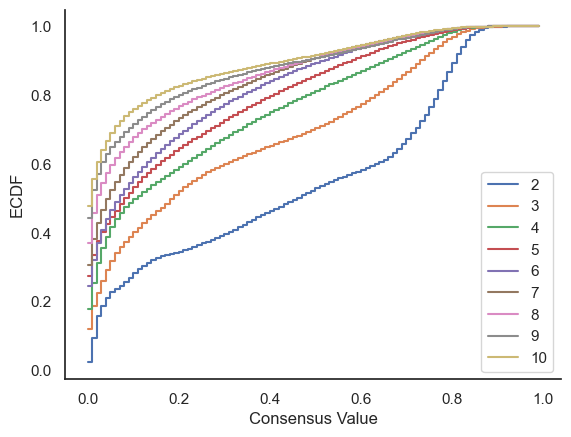

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

plot_data = pd.DataFrame()

for k, cdf in cdfs.items():

    sns.lineplot(
        x=cdf[1],
        y=cdf[0],
        ax=ax,
        label=k,
        drawstyle="steps-post",
    )

    temp_df = pd.DataFrame(
        {
            "Consensus Value": cdf[1],
            "ECDF": cdf[0],
            "K": [k for _ in range(len(cdf[0]))],
        }
    )

    plot_data = pd.concat([plot_data, temp_df])

sns.despine()

ax.set_xlabel("Consensus Value")
ax.set_ylabel("ECDF")

fig.savefig(
    "cdfs.pdf", dpi=300, bbox_inches="tight"
)


In [27]:

auc_data = []

for k, cdf in cdfs.items():

    auc_data.append(np.trapz(cdf[0], cdf[1]))

In [28]:
auc_deltas = []

for left, right in zip(auc_data[:-1], auc_data[1:]):

    auc_delta = right - left

    auc_deltas.append(auc_delta)



In [29]:
auc_plot_data = pd.DataFrame(
    {
        "AUC": auc_deltas,
        "K": range(len(auc_deltas)),
    }
)

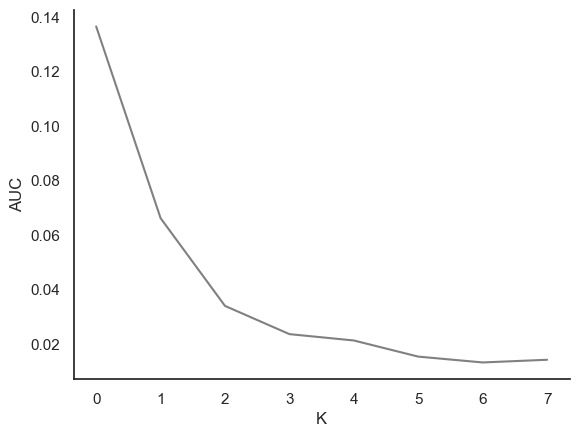

In [31]:
fig, ax = plt.subplots()

sns.lineplot(
    data=auc_plot_data,
    x="K",
    y="AUC",
    ax=ax,
    c="gray",
)

sns.despine()

fig.savefig(
    "auc_plot.pdf", dpi=300, bbox_inches="tight"
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


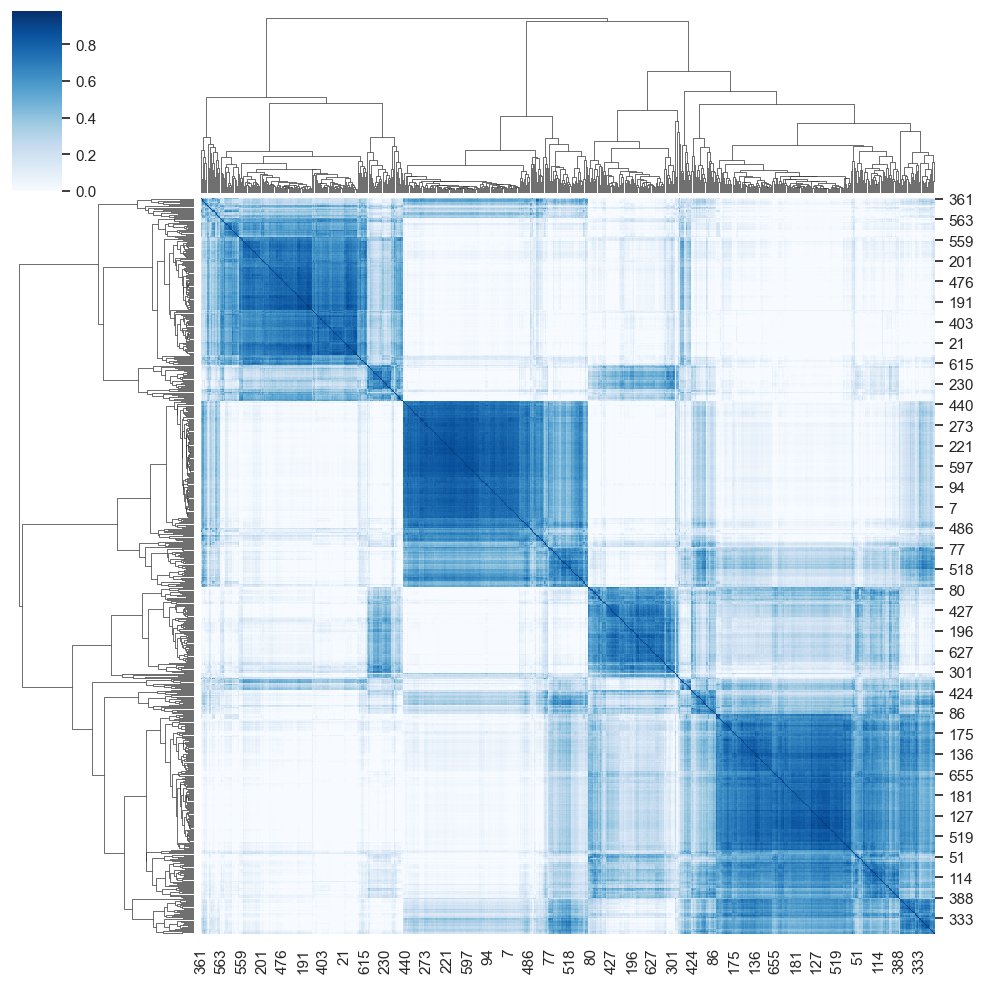

In [35]:
for k in [4]:

    g = sns.clustermap(
        data=clusterer_results[k].coassoc_matrix,
        cmap="Blues",
    )

    g.savefig(
        f"cluster_results-{k}.pdf",
        dpi=300,
        bbox_inches="tight",
    )

In [36]:
plot_data = pd.DataFrame()

for k, cdf in cdfs.items():

    temp_df = pd.DataFrame(
        {
            "Consensus Values": cdf[2],
            "K": [k for _ in range(len(cdf[2]))],
        }
    )

    plot_data = pd.concat([plot_data, temp_df])

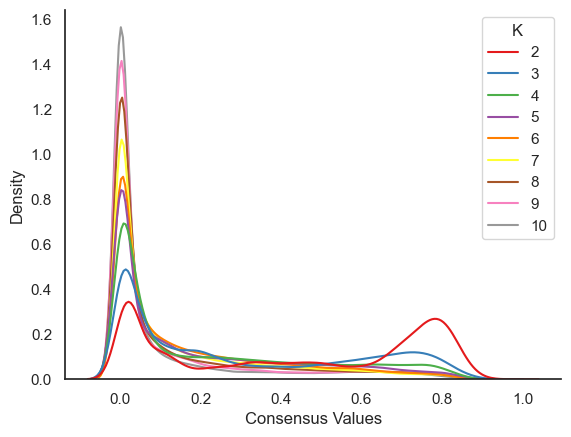

In [41]:
fig, ax = plt.subplots()


sns.kdeplot(
    data=plot_data,
    x="Consensus Values",
    hue="K",
    palette="Set1",
    ax=ax
)
sns.despine()

fig.savefig(
    "kdeplot.pdf", dpi=300, bbox_inches="tight"
)

In [39]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range_n_clusters:

    col = f"Consensus Labels{k}"

    silhouette_scores.append(silhouette_score(training_data[clinical_columns], training_data[col]))


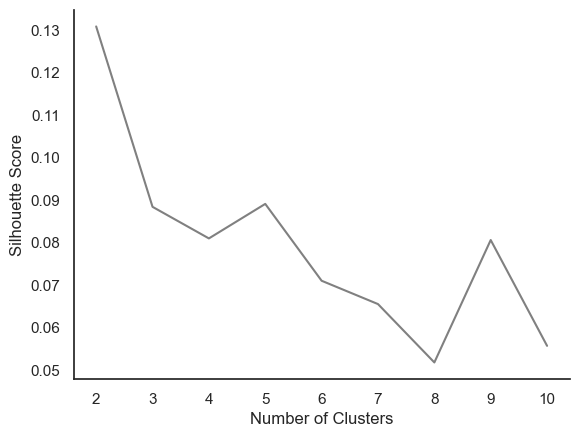

In [42]:
fig, ax = plt.subplots()

sns.lineplot(
    x=range_n_clusters,
    y=silhouette_scores,
    ax=ax,
    c="gray",
)

sns.despine()

ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
fig.savefig(
    "silhouette.pdf", dpi=300, bbox_inches="tight"
)

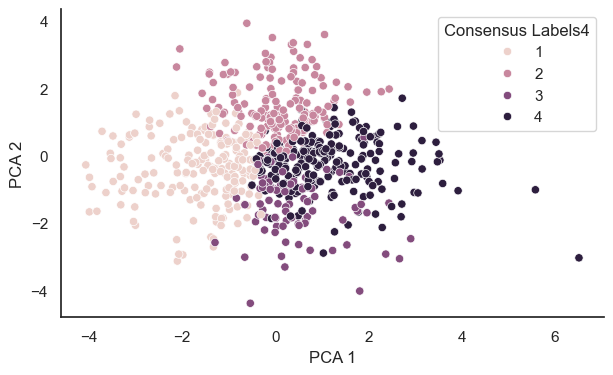

In [46]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue="Consensus Labels4",
    ax=ax,
)
sns.despine()

fig.set_size_inches(
    (7, 4)
)

fig.savefig(
    "clusters.pdf", dpi=300, bbox_inches="tight"
)

sao2_ambulance


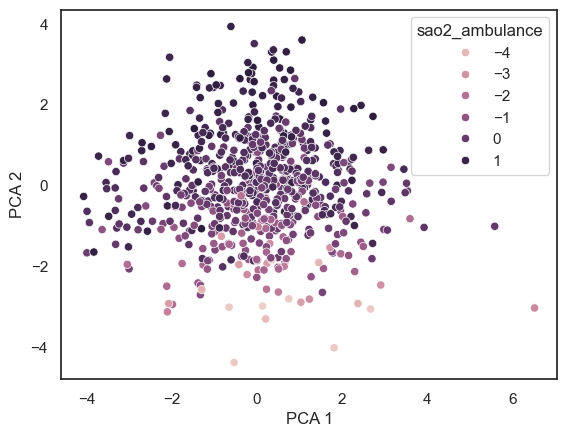

resp_frequency_ambulance


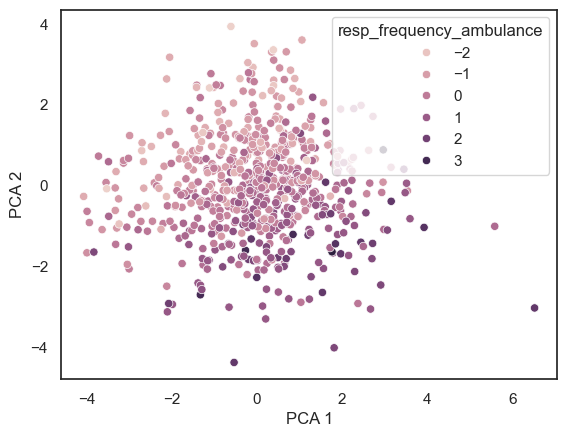

heart_rate_ambulance


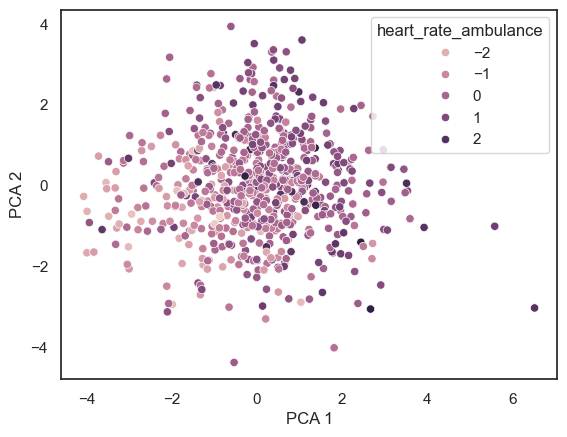

syst_bp_ambulance


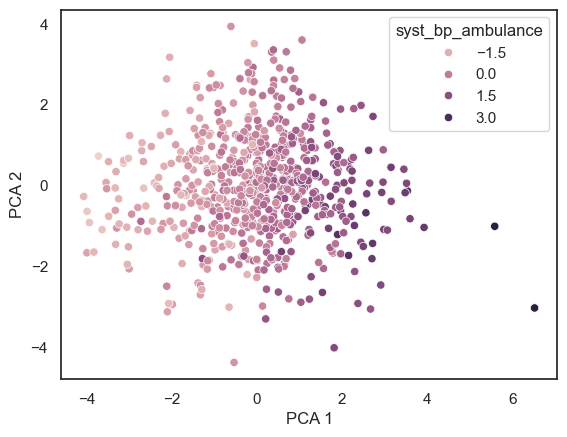

map_ambulance


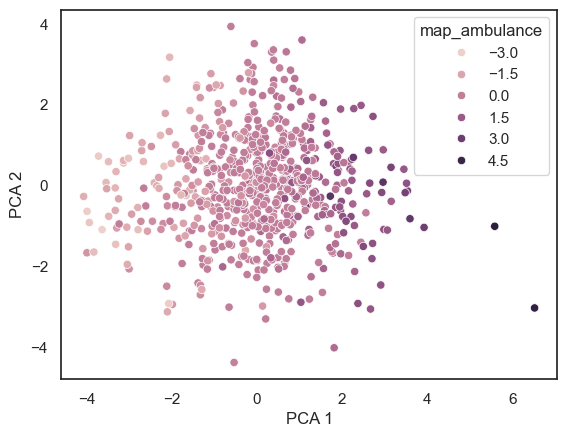

mental_status_ambulance


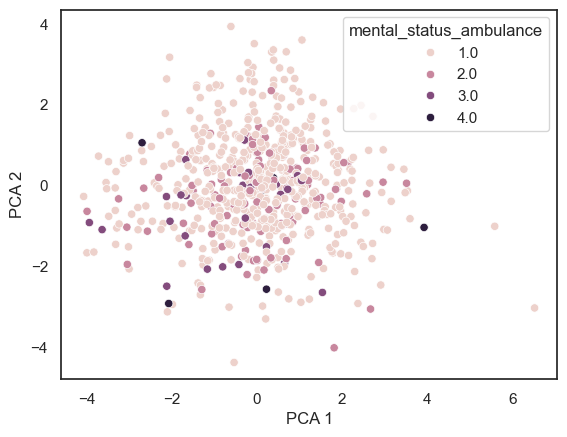

temperature_ambulance


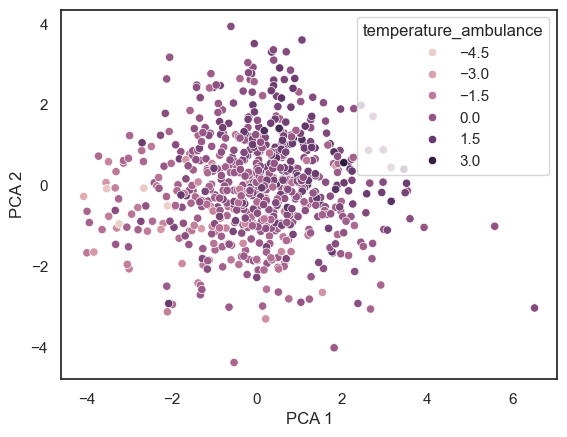

crea_emergency_department


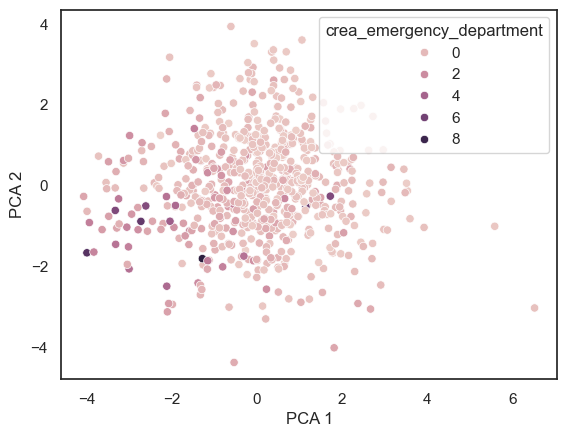

bili_emergency_department


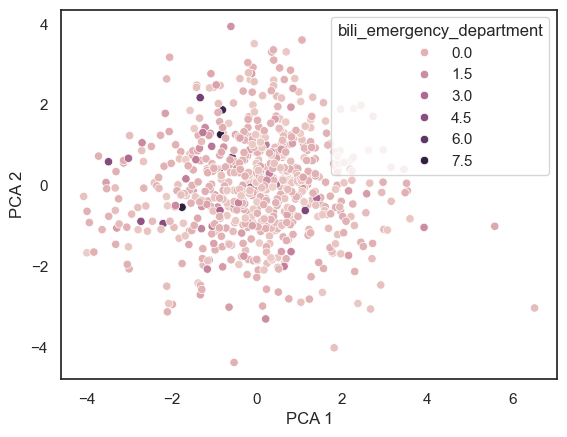

crp_day1


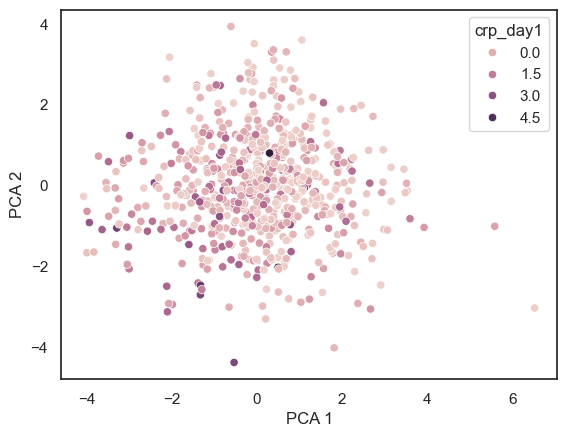

trc_emergency_department


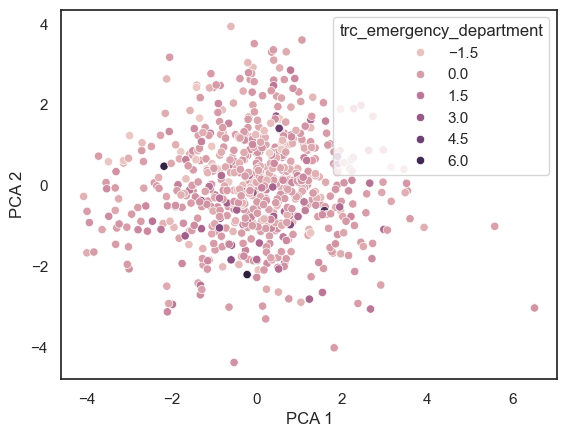

sex


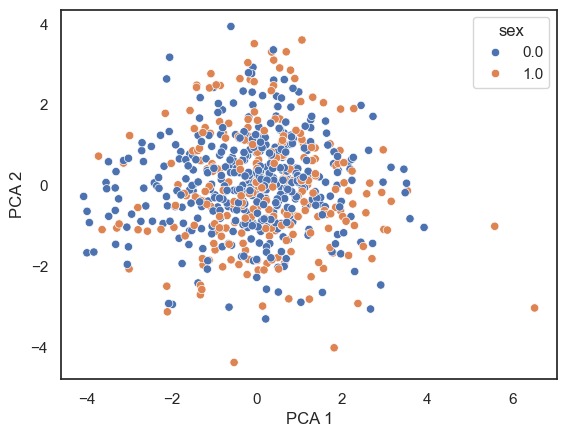

age


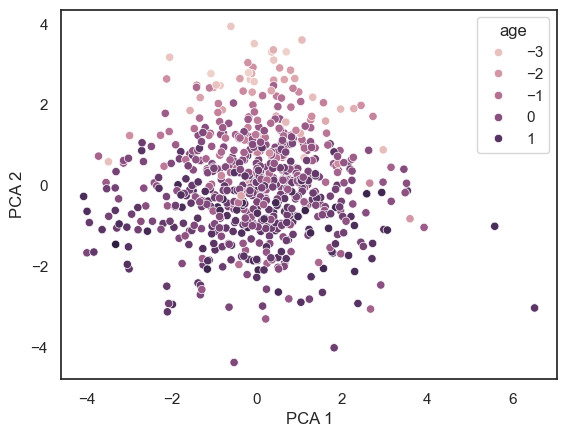

In [47]:
for col in clinical_columns:

    print(col)
    sns.scatterplot(
        data=training_data,
        x="PCA 1",
        y="PCA 2",
        hue=col
    )
    plt.show()

In [48]:

col = f"Consensus Labels4"

cluster_names = training_data[col].unique()

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_61123/3890825705.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_61123/3890825705.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_61123/3890825705.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_61123/3890825705.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

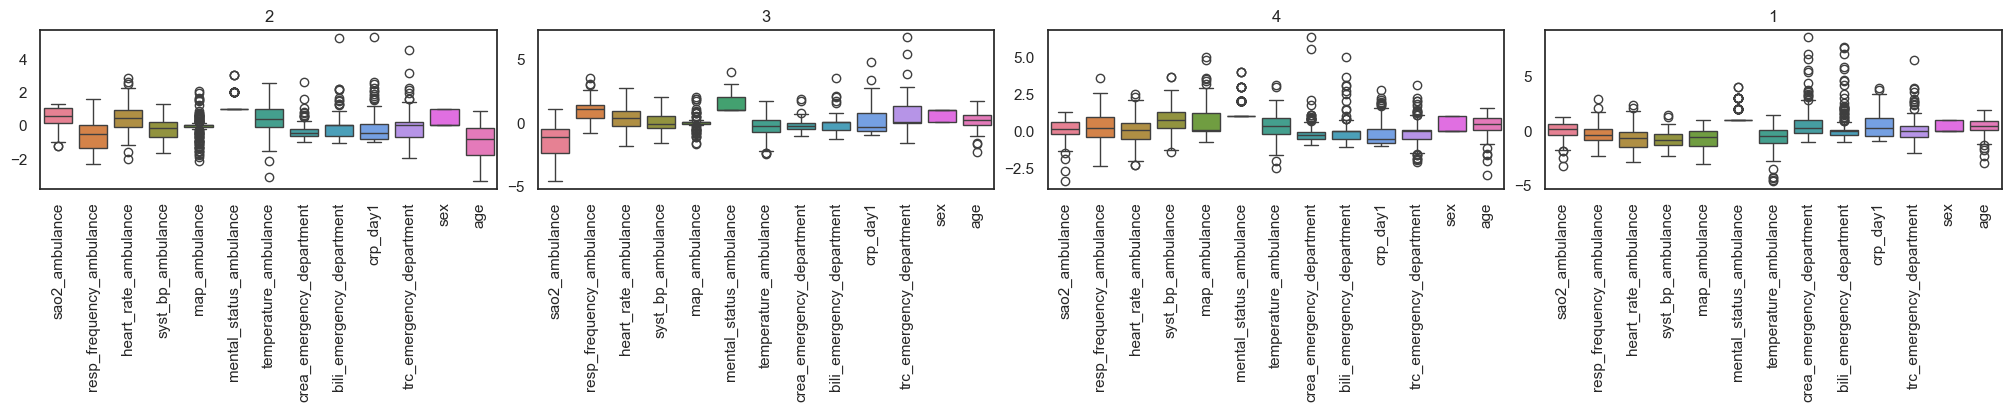

In [49]:
cluster_centroids = dict()

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    layout="constrained",
)

for i, cluster_name in enumerate(cluster_names):

    subset_training_data = training_data[training_data[col] == cluster_name].copy()

    cluster_centroids[cluster_name] = subset_training_data[clinical_columns].mean()

    sns.boxplot(
        data=subset_training_data[clinical_columns],
        ax=axs[i]
    )

    axs[i].set_title(cluster_name)

    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)

fig.set_size_inches((20, 4))

In [50]:
long = training_data.melt(
    id_vars=[col],    value_vars=clinical_columns,

)
long[col] = long[col].astype("category")

In [51]:
long

,Consensus Labels4,variable,value
0,2,sao2_ambulance,-0.440508
1,3,sao2_ambulance,-1.577464
2,4,sao2_ambulance,0.582753
3,1,sao2_ambulance,-1.008986
4,2,sao2_ambulance,-0.213116
...,...,...,...
8835,1,age,0.295378
8836,4,age,0.009216
8837,3,age,0.058323
8838,4,age,0.413090


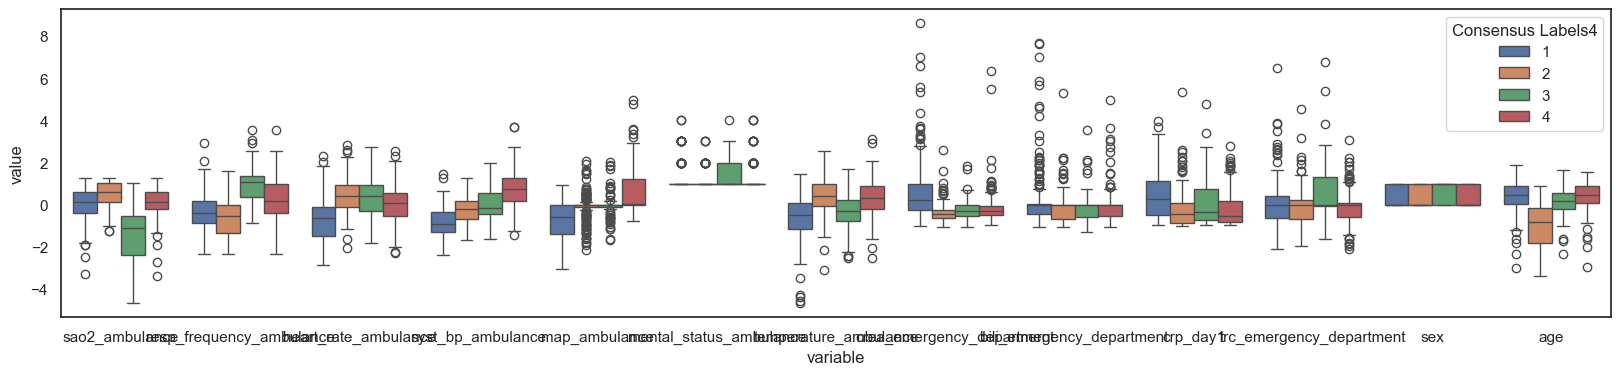

In [52]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
)
sns.boxplot(
    data=long,
    x="variable",
    y="value",
    hue="Consensus Labels4",
    ax=axs
)

#axs.set_xticklabels(axs.get_xticklabels(), rotation=90)

fig.set_size_inches((20, 4))

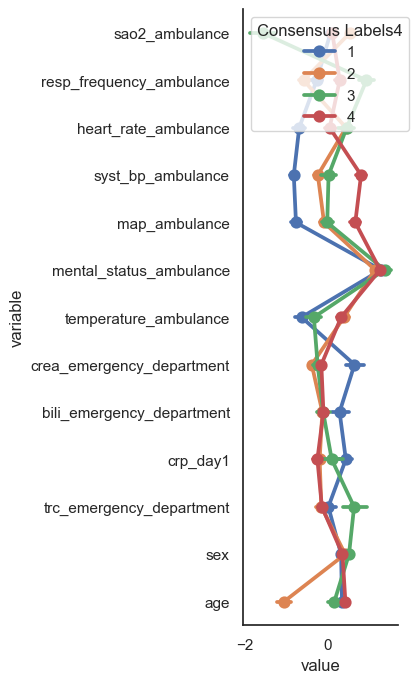

In [65]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
)
sns.pointplot(
    data=long,
    y="variable",
    x="value",
    hue="Consensus Labels4",
    ax=axs
)

#axs.set_xticklabels(axs.get_xticklabels(), rotation=90)

sns.despine()

fig.set_size_inches((2, 8))

fig.savefig(
    "cluster_variables.pdf", dpi=300, bbox_inches="tight"
)

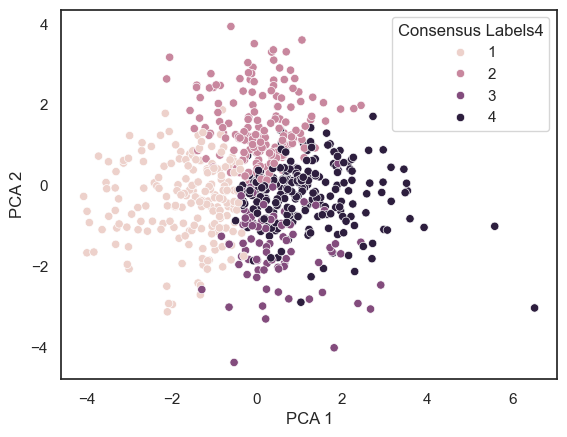

In [56]:

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue=col
)
plt.show()

In [57]:
centroids = pd.DataFrame.from_dict(cluster_centroids, orient="index")

In [58]:
centroid_locations = pca.transform(centroids)

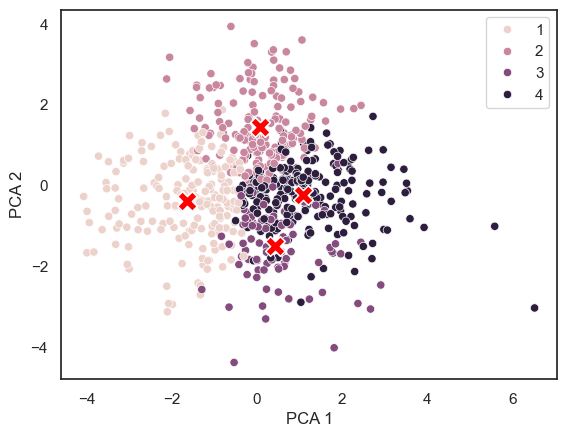

In [59]:

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue=col
)

sns.scatterplot(
    x=centroid_locations[:, 0],
    y=centroid_locations[:, 1],
    c="red",
    marker="X",
    s=200
)

plt.show()

In [60]:
from sklearn.metrics import silhouette_samples

training_data['Silhoutte Samples'] = silhouette_samples(
    training_data[clinical_columns],
    labels=training_data["Consensus Labels4"],
)




In [61]:
training_data = training_data.sort_values(
    by=["Consensus Labels4", "Silhoutte Samples"],
    ascending=[True, True]
)

In [62]:
training_data['X_axis'] = np.arange(training_data.shape[0])

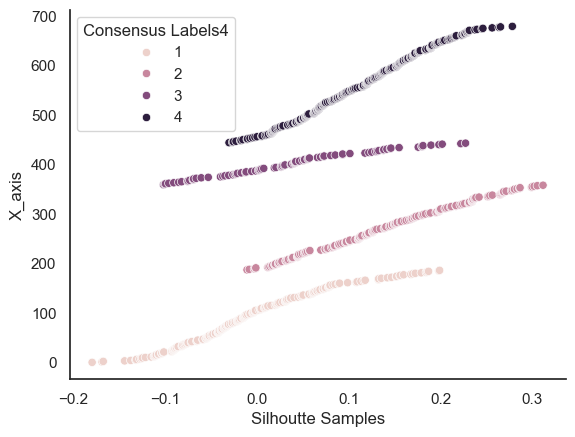

In [63]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    y="X_axis",
    x="Silhoutte Samples",
    hue="Consensus Labels4",
    ax=ax
)

sns.despine()

fig.savefig(
    "silhouette_samples.pdf", dpi=300, bbox_inches="tight"
)

<Axes: xlabel='Silhoutte Samples', ylabel='Count'>

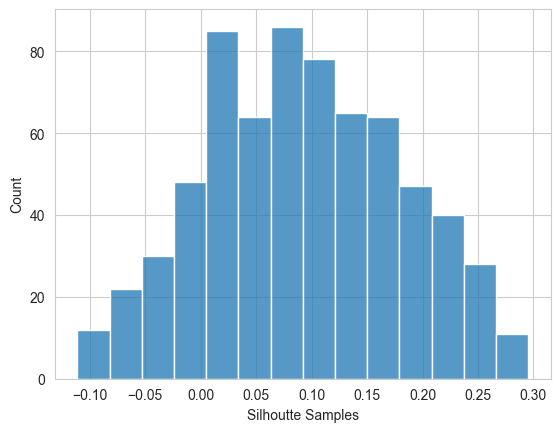

In [48]:
sns.histplot(
    data=training_data,
    x="Silhoutte Samples",
)

In [66]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)

In [67]:
neighbors.fit(training_data[clinical_columns])

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [68]:
dist, ind = neighbors.kneighbors(training_data[clinical_columns])

In [69]:
training_data['30_day_mortality'] = np.where(
    training_data['survival_days'] <= 30, 1, 0
)

In [70]:
mortality_rates = []

for i in range(ind.shape[0]):

    sample_neigh_ind = ind[i, :]

    sample_neighbors = training_data.iloc[sample_neigh_ind, :]
    mortality_rates.append(
        sample_neighbors['30_day_mortality'].sum() / sample_neighbors.shape[0]
    )

training_data['30 Day Mortality'] = mortality_rates

In [80]:
sns.set_theme(style="white")

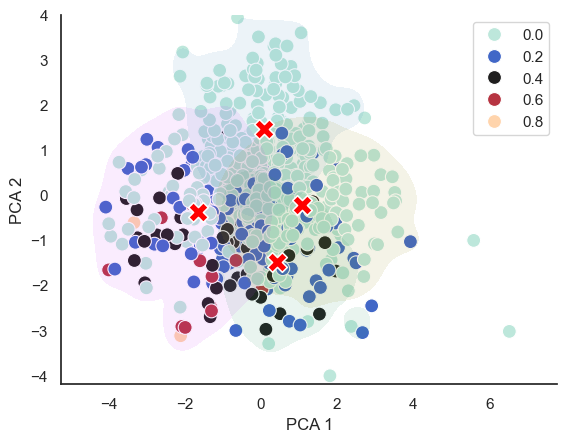

In [81]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue="30 Day Mortality",
    ax=ax,
    palette="icefire",
    s=100
)

sns.kdeplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue="Consensus Labels4",
    alpha=0.1,
    palette="viridis",
    ax=ax,
    levels=2,
    fill=True,

)

sns.scatterplot(
    x=centroid_locations[:, 0],
    y=centroid_locations[:, 1],
    c="red",
    marker="X",
    s=200
)

ax.set_ylim([-4.2, 4])
#fig.set_size_inches((10, 7))

sns.despine()

fig.savefig(
    "cluster_gradients.pdf", dpi=300, bbox_inches="tight"
)


In [72]:
centroids

,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,crp_day1,trc_emergency_department,sex,age
2,0.539704,-0.578686,0.446560,-0.234858,-0.085103,1.145349,0.395738,-0.380859,-0.125918,-0.191630,-0.149795,0.424419,-1.049236
3,-1.564088,0.937608,0.462060,0.024111,-0.007531,1.376471,-0.329970,-0.239679,-0.106276,0.100140,0.639778,0.517647,0.163394
4,0.113878,0.292496,0.050255,0.808159,0.668879,1.266949,0.327260,-0.150412,-0.099825,-0.245744,-0.136798,0.360169,0.429616
1,0.070819,-0.263058,-0.684190,-0.814863,-0.762447,1.288770,-0.627020,0.649078,0.290106,0.440877,0.019614,0.326203,0.348614


In [82]:
from scipy.spatial import distance

centroid_distances = []

for idx, row in training_data.iterrows():

    centroid = centroids.loc[row['Consensus Labels4'], :]

    centroid = centroid[clinical_columns].to_numpy()

    target = row[clinical_columns].to_numpy()

    dist = distance.euclidean(centroid, target)

    centroid_distances.append(dist)

training_data['centroid_distance'] = centroid_distances

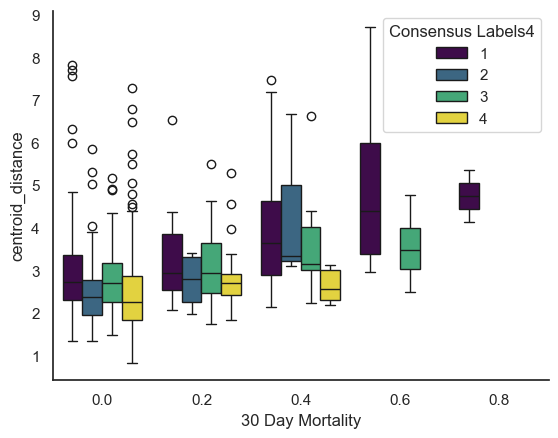

In [83]:
fig, ax = plt.subplots()

sns.boxplot(
    data=training_data,
    x="30 Day Mortality",
    y="centroid_distance",
    hue="Consensus Labels4",
    palette="viridis",
    ax=ax
)

sns.despine()
fig.savefig(
    "centroid_distances.pdf", dpi=300, bbox_inches="tight"
)

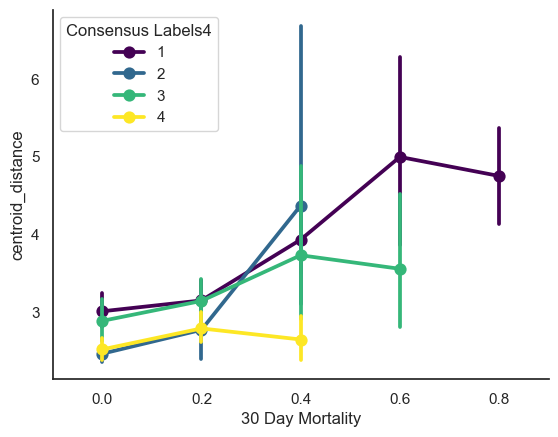

In [84]:
fig, ax = plt.subplots()
sns.pointplot(
    data=training_data,
    x="30 Day Mortality",
    y="centroid_distance",
    hue="Consensus Labels4",
    palette="viridis",
    ax=ax
)

sns.despine()
fig.savefig(
    "centroid_distances_pointplot.pdf", dpi=300, bbox_inches="tight"
)